#Define Problem Statement and perform Exploratory Data Analysis

 - Yulu, a leading micro-mobility service provider in India, is experiencing a decline in revenue and seeks to identify the key factors influencing the demand for its shared electric cycles. The objective is to analyze various potential variables—such as location, weather, time of day, and socio-economic conditions—to determine their impact on usage patterns.
 - The company aims to understand :
    - factors are most significant in predicting demand
    - how well these factors explain variations in cycle usage, in order to optimize service delivery and drive growth.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import kruskal
from scipy.stats import chisquare, chi2_contingency

 # Importing Data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/01. Data Set for Colab Notebooks/bike_sharing.csv')
df.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


 # Basic Data Analysis





In [ ]:
df.shape

(10886, 12)

 - The data set has 10886 rows and 12 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


 - Target / Dependent Variable : count
 - Features / Independent Variable : rest all
 - String / Object : datetime
 - Continuous : temp, atemp, windspeed
 - Discrete : season, holiday, workingday, weather, humidity , casual, registered, count




In [ ]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


 - It describes the distribution of the numeric attributes non-graphically

In [ ]:
df.describe(include="O")

,datetime
count,10886
unique,10886
top,2012-12-19 23:00:00
freq,1


- Column wise - count of unique values

In [ ]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


 - It shows the number of unique values under each column

- Missing Value Detection

In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


- There is no null value in the data set

# Anlysis - Detailed

In [ ]:
col = ['season','weather','workingday','holiday']

In [ ]:
def dist(data,col) :
  print("Variable Name : ", col)
  print("Unique Values : ",data[col].unique())
  print("Value Counts : ",data[col].value_counts())
  print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~')

In [ ]:
for i in col :
  dist(df,i)

Variable Name :  season
Unique Values :  [1 2 3 4]
Value Counts :  season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Variable Name :  weather
Unique Values :  [1 2 3 4]
Value Counts :  weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Variable Name :  workingday
Unique Values :  [0 1]
Value Counts :  workingday
1    7412
0    3474
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Variable Name :  holiday
Unique Values :  [0 1]
Value Counts :  holiday
0    10575
1      311
Name: count, dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~


 - Weather 4 has only 1 data point : should be removed

<Axes: title={'center': 'Correlation Heatmap'}>

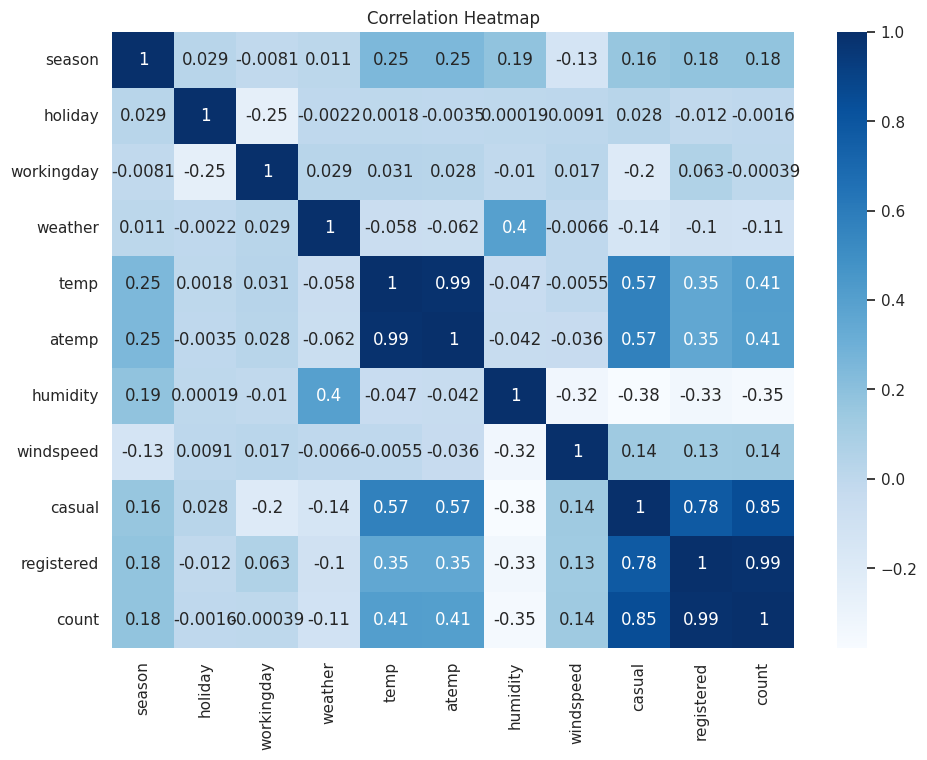

In [ ]:
plt.figure(figsize=(11,8))
plt.title('Correlation Heatmap')
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(method = 'spearman'),annot=True,cmap='Blues') #Spearman correlation as all the attributes except "temp" and "atemp" are Ordinal numbers

  - Feeling temperature and actual temperature in celcius are very highly correlated, as mostly they are almost same
  - Casual, Registered, and Count are correlated to each other

- Hence we'll drop casual, registered, atemp

In [ ]:
df1 = df.drop(columns = ['casual','registered','atemp'])

In [ ]:
df1.head(3)

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,32


#Outlier Detection

In [ ]:
col = ['season','weather','workingday','holiday']

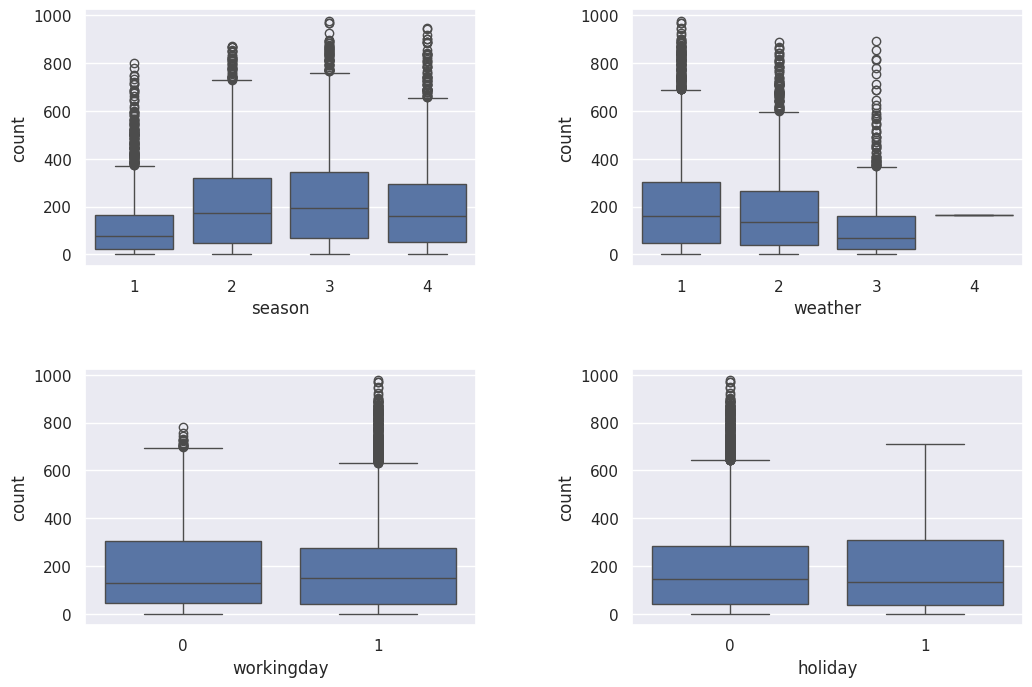

In [ ]:
sns.set(style="darkgrid")
fig = plt.figure(figsize=(15,22))
fig.subplots_adjust(hspace=0.4,wspace=0.4,  right=0.75)

for i in range(1, len(col) + 1):
  plt.subplot(5, 2, i)
  sns.boxplot(data=df1, x=col[i-1], y ='count')

<Axes: xlabel='count', ylabel='Density'>

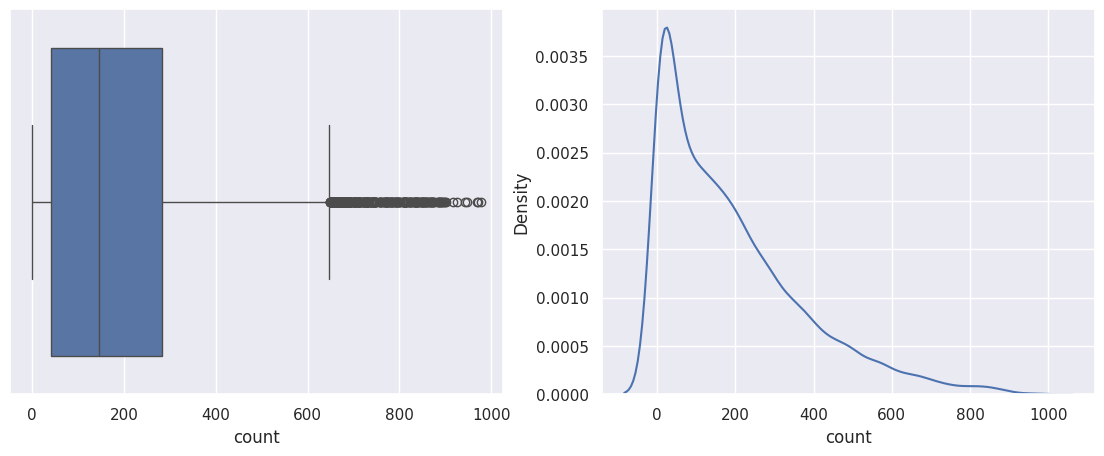

In [ ]:
plt.figure(figsize=(14,5))
fig.subplots_adjust(hspace=0.4,wspace=0.4,  right=0.75)

plt.subplot(1,2,1)
sns.boxplot(data=df1, x='count')

plt.subplot(1,2,2)
sns.kdeplot(x = df1['count'])

- Distribution of "count" is right skewed which is expected as "count" can not be negative

In [ ]:
df['count'].describe()

,count
count,10886.000000
mean,191.574132
std,181.144454
min,1.000000
25%,42.000000
50%,145.000000
75%,284.000000
max,977.000000


In [ ]:
Q1 = np.percentile(df1['count'],25)
Q3 = np.percentile(df1['count'],75)
IQR = Q3 - Q1
UL = Q3 + 1.5 * IQR
LL = Q1 - 1.5 * IQR
print('Upper Limit : ',UL)
print('Lower Limit : ',LL)

Upper Limit :  647.0
Lower Limit :  -321.0


In [ ]:
# Outlier exists for "count" columns
# We need to understand if these outliers make any sense w.r.t the business case
# if not then we'll remove the using IQR method
# if it makes sense then we can reduce the effect of outliers using log transformation

- There is no outlier on the left side as "count" can't be negative
- Any "count" > 647 is an outlier which is natural as per current scenario

#Hypothesis Testing

In [ ]:
col = ['season','weather','workingday','holiday']

In [ ]:
for i in col :
  print(df1.groupby(i)['count'].describe())
  print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

         count        mean         std  min   25%    50%    75%    max
season                                                                
1       2686.0  116.343261  125.273974  1.0  24.0   78.0  164.0  801.0
2       2733.0  215.251372  192.007843  1.0  49.0  172.0  321.0  873.0
3       2733.0  234.417124  197.151001  1.0  68.0  195.0  347.0  977.0
4       2734.0  198.988296  177.622409  1.0  51.0  161.0  294.0  948.0
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
          count        mean         std    min    25%    50%    75%    max
weather                                                                   
1        7192.0  205.236791  187.959566    1.0   48.0  161.0  305.0  977.0
2        2834.0  178.955540  168.366413    1.0   41.0  134.0  264.0  890.0
3         859.0  118.846333  138.581297    1.0   23.0   71.0  161.0  891.0
4           1.0  164.000000         NaN  164.0  164.0  164.0  164.0  164.0
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# 1. Hypothesis Testing for validation of Working Day effect

In [ ]:
df1.groupby('workingday')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
0,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
1,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


In [ ]:
# Ho : The mean demand of the bikes on a Workingday is similar or greater than a non-working day
# Ha : The mean demand of the bikes on a Workingday is less that of a non-working day


# Confidence Level : 95%
# alpha : 0.05

In [ ]:
wd = df1[df1['workingday']==1]['count'].sample(2000)
nwd = df1[df1['workingday']==0]['count'].sample(2000)

In [ ]:
test_stat, p_value = ttest_ind(wd, nwd, alternative = 'less')
print('Test Statistic : ', test_stat)
print('P-Value : ', p_value)

Test Statistic :  0.9103489481692773
P-Value :  0.8186533040228436


- As p_value is greater than alpha we fail to reject Ho
    - Ho : The mean demand of the bikes on a Workingday is similar or greater than a non-working day

# 2. Hypothesis Testing for Weather effect

In [ ]:
df1.groupby('weather')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
4,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0


In [ ]:
df1 = df1[~(df1['weather']==4)]

In [ ]:
df1.groupby('weather')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
2,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0
3,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0


- Pre-requisites for ANOVA :
    - Samples are independent
    - Test of Normality - Shapiro Wilk Test
    - Equal variance - Levene's Test

In [ ]:
# Shapiro Wilk Test

# Ho : Count follows Gaussian Distribution
# Ha : Count does not follow Gaussian Distribution

# Confidence Level : 95%
# alpha : 0.05

In [ ]:
test_stat, p_value = shapiro(df1['count'])
print('Test Statistic : ', test_stat)
print('P-Value : ', p_value)

Test Statistic :  0.8783644990326159
P-Value :  5.390765379788034e-68


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10885.
  res = hypotest_fun_out(*samples, **kwds)


 - p_value is greater than alpha. Hence, we reject Ho
      - Ha : Count does not follow Gaussian Distribution

In [ ]:
# Levene's Test

# Ho : Variances are equal
# Ha : Variances are not equal

# Confidence Level : 95%
# alpha : 0.05

In [ ]:
weather1 = df1[df1['weather']==1]['count'].sample(500)
weather2 = df1[df1['weather']==2]['count'].sample(500)
weather3 = df1[df1['weather']==3]['count'].sample(500)

In [ ]:
test_stat, p_value = levene(weather1,weather2,weather3)
print('Test Statistic : ', test_stat)
print('P-Value : ', p_value)

Test Statistic :  20.047501810573312
P-Value :  2.558794827445126e-09


 - p_value is greater than alpha. Hence, we reject Ho
      - Ha : Variances are not equal

In [ ]:
#ANOVA

# Ho : Mean count of rides booked in differen weather condition are equal
# Ha : Mean count of rides booked in differen weather condition are different

# Confidence Level : 95%
# alpha : 0.05

In [ ]:
test_stat, p_value = f_oneway(weather1, weather2, weather3)
print('Test Statistic : ', test_stat)
print('P-Value : ', p_value)

Test Statistic :  28.070827960533073
P-Value :  1.076547738350539e-12


- As p_value is less than alpha we reject Ho
    - Ha : Mean count of rides booked in different weather condition are different

  ### But this result may not be accurate as Shapiro and Levene's tests failed

In [ ]:
#Kruskal Wallis Test

# Ho : Median of rides count in different weather condition are equal
# Ha : Median of rides count in different weather condition are different

# Confidence Level : 95%
# alpha : 0.05

In [ ]:
test_stat, p_value = kruskal(weather1, weather2, weather3)
print('Test Statistic : ', test_stat)
print('P-Value : ', p_value)

Test Statistic :  61.29871970644983
P-Value :  4.88823573839245e-14


- As p_value is less than alpha we reject Ho
    - Ha : Median of ride counts in differen weather condition are different

# 3. Hypothesis Testing for Season effect

In [ ]:
df1.groupby('season')['count'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2685.0,116.325512,125.293931,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


 - As we have already seen "count" does not follow Gaussian (which is an assumption for ANOVA) we'll perform Kruskal Wallis Test (non-parametric)

In [ ]:
season1 = df1[df1['season']==1]['count'].sample(2000)
season2 = df1[df1['season']==2]['count'].sample(2000)
season3 = df1[df1['season']==3]['count'].sample(2000)
season4 = df1[df1['season']==3]['count'].sample(2000)

In [ ]:
#Kruskal Wallis Test

# Ho : Median of ride counts in different season are equal
# Ha : Median of ride counts in different season are different

# Confidence Level : 95%
# alpha : 0.05

In [ ]:
test_stat, p_value = kruskal(season1, season2, season3,season4)
print('Test Statistic : ', test_stat)
print('P-Value : ', p_value)

Test Statistic :  580.1790751247803
P-Value :  1.9961000139643586e-125


- As p_value is less than alpha we reject Ho
    - Ha : Median of rides count in different seasons are different

# 4. Hypothesis Testing to validate if weather is dependent on season

- As it is Categorical Vs categorical data, we'll use Chi Square test if Independence

In [ ]:
dict_w = {1 : "sunny",2 : "gloomy", 3 : "snowy", 4: "rainy"}
df1['weather_decoded'] = df1['weather'].map(dict_w)

In [ ]:
dict_s = {1 : "spring",2 : "summer", 3 : "fall", 4: "winter"}
df1['season_decoded'] = df1['season'].map(dict_s)

In [ ]:
ct_w_s = pd.crosstab(df1['weather_decoded'],df1['season_decoded'])
ct_w_s

season_decoded,fall,spring,summer,winter
weather_decoded,,,,
gloomy,604,715,708,807
snowy,199,211,224,225
sunny,1930,1759,1801,1702


In [ ]:
#Ho : Weather conditions are independent of season
#Ha : Weather conditions dependent on season

# Confidence Level : 95%
# alpha : 0.05

In [ ]:
chi = chi2_contingency(ct_w_s)
print(chi)

Chi2ContingencyResult(statistic=np.float64(46.10145731073249), pvalue=np.float64(2.8260014509929343e-08), dof=6, expected_freq=array([[ 711.55920992,  699.06201194,  711.55920992,  711.81956821],
       [ 215.67726229,  211.8892972 ,  215.67726229,  215.75617823],
       [1805.76352779, 1774.04869086, 1805.76352779, 1806.42425356]]))


- As p_value is less than alpha we reject Ho
    - Ha : Weather conditions dependent on season

# Insights
- The data set has 10886 rows and 12 columns
- Target / Dependent Variable : count
- Features / Independent Variable : rest all
- String / Object : datetime
- Continuous : temp, atemp, windspeed
- Discrete : season, holiday, workingday, weather, humidity , casual, registered, count
- There is no null value in the data set
- Weather 4 has only 1 data point : should be removed

- Feeling temperature and actual temperature in celcius are very highly correlated, as mostly they are almost same
- Casual, Registered, and Count are correlated to each other
- “count” does not follow Gaussian diatribution
- Distribution of "count" is right skewed which is expected as "count" can not be negative
- There is no outlier on the left side as "count" can't be negative
- Any "count" > 647 is an outlier which is natural as per current scenario


# Hypothesis Test Result
-	The mean demand of the bikes on a Workingday is similar or greater than a non-working day
-	Median of ride counts in different weather condition are different
-	Median of ride counts in different seasons are different
-	Weather conditions dependent on season


#Findings
 - Demand for bikes increases in Season 3 i.e. in fall
 - Demand for bike shoots up in Weather 1 scenario i.e. when it's sunny
 - Demand for bikes are higher in a workingday
 - Demand for bikes is less in a non-working day

#Recommendations
- Dynamic pricing based on demand and weather. Demand is affected by weather and time of day
    - Introduce Surge pricing in the high-demand periods
    - Offer dicount in the off-peak hours

- Seasonal maintenance and fleet planning
    - demand peaks in season 3 and drops in season 1
    - maintenance of the fleet can be done in season 1

- Optimize fleet allocation by time of day and location

- Enhance user engagement on non-working days like weekend offers, group rides etc.

- Promote eco-friendly campaigns